# DDPG Training Example on ImprovedB747Env

This notebook demonstrates training a DDPG agent from `tensoraerospace/agent/ddpg/model.py` on the `ImprovedB747Env` environment from `tensoraerospace/envs/b747.py`.

## About the Algorithm

**DDPG (Deep Deterministic Policy Gradient)** is an off-policy actor-critic algorithm for continuous action spaces:
- **Actor** selects continuous actions deterministically
- **Critic** estimates Q-values
- **Target networks** with soft updates for stability
- **Replay buffer** for experience reuse
- **Observation normalization** (Welford's algorithm) for stable training

## About the Environment

`ImprovedB747Env` provides:
- **Reference tracking**: follow pitch angle (theta) signals
- **LQR-style reward**: penalizes tracking error, control effort, and state deviations
- **Normalized actions**: symmetric `[-1, 1]` action space, mapped to elevator deflections

In [1]:
# Optional installs (run if needed)
# %pip install tensorboard tqdm --quiet

import os
import numpy as np
import torch

from tensoraerospace.envs.b747 import ImprovedB747Env
from tensoraerospace.agent.ddpg.model import DDPG

# Device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu"))
print("Using device:", DEVICE)

# Reproducibility
np.random.seed(1)
_ = torch.manual_seed(1)


Using device: mps


In [ ]:
# Build environment
from tensoraerospace.signals.standart import sinusoid_vertical_shift
from tensoraerospace.utils import convert_tp_to_sec_tp, generate_time_period

# Time base
dt = 0.1
_tp = generate_time_period(tn=20, dt=dt)
tps = convert_tp_to_sec_tp(_tp, dt=dt)
number_time_steps = len(_tp)
# Reference theta (radians)
reference_signals = np.reshape(
    sinusoid_vertical_shift(
        tp=np.asarray(tps),
        frequency=0.05/dt,
        amplitude=np.deg2rad(1.0),
        vertical_shift=0.0,
    ),
    [1, -1],
)

# Initial state [u, w, q, theta] (SI units; angles in rad)
init_state = np.array([0.0, 0.0, 0.0, 0.0], dtype=np.float32)

# Env
env = ImprovedB747Env(
    initial_state=init_state,
    reference_signal=reference_signals,
    number_time_steps=number_time_steps,
    dt=dt,
    initial_elevator_deg=0.0,
)

obs, info = env.reset()
print("Obs shape:", np.array(obs).shape)
print("Action space:", env.action_space)
print("Observation space:", env.observation_space)


In [3]:
# Create DDPG agent (tuned hyperparams)
# General tips for ImprovedB747Env:
# - Slightly higher gamma improves tracking stability
# - Softer target update and grad clipping reduce oscillations
# - Larger batch and buffer help value estimation
value_lr = 3e-4
policy_lr = 1e-4
replay_buffer_size = 200_000

# New parameter: normalize_observations
# Enables automatic normalization of input states using running mean/std
# This helps with:
# - Faster convergence (normalized inputs to neural networks)
# - Better stability (all features on similar scale)
# - Improved generalization
# Set to False if your environment already normalizes observations
normalize_observations = True

agent = DDPG(
    env, 
    value_lr=value_lr, 
    policy_lr=policy_lr, 
    replay_buffer_size=replay_buffer_size,
    normalize_observations=normalize_observations
)

# Optional: adjust OU noise for smoother exploration
# By default (theta=0.15, sigma~0.3) it may be too jittery for pitch control
agent.ou_noise.theta = 0.1
agent.ou_noise.max_sigma = 0.01
agent.ou_noise.min_sigma = 0.002
agent.ou_noise.decay_period = 200_000

# Check devices
print("Actor device:", next(agent.policy_net.parameters()).device)
print("Critic device:", next(agent.value_net.parameters()).device)
print("Observation normalization:", "Enabled" if agent.normalize_observations else "Disabled")

# Note: Action scaling is automatic
# PolicyNetwork automatically scales tanh output [-1, 1] to action_space bounds
print(f"Action space bounds: {env.action_space.low} to {env.action_space.high}")


Actor device: cpu
Critic device: cpu
Observation normalization: Enabled
Action space bounds: [-1.] to [1.]


## Observation Normalization

Observation normalization uses **Welford's algorithm** for online computation of running mean and variance:

```
normalized_obs = (obs - running_mean) / sqrt(running_var + eps)
```

This approach:
- Computes statistics incrementally (no need to store full history)
- Numerically stable even with large observation counts
- Helps the neural network learn faster by standardizing inputs

The agent handles normalization internally — no manual preprocessing needed.

In [4]:
# Inspect normalization statistics (optional - run after training)
if agent.obs_rms is not None:
    print("Observation normalization statistics:")
    print(f"  Mean: {agent.obs_rms.mean}")
    print(f"  Std:  {np.sqrt(agent.obs_rms.var)}")
    print(f"  Count: {agent.obs_rms.count:.0f} samples")
else:
    print("Observation normalization is disabled")


Observation normalization statistics:
  Mean: [0. 0. 0. 0.]
  Std:  [1. 1. 1. 1.]
  Count: 0 samples


In [9]:
# Quick run (short) — optional for testing
# With observation normalization, convergence should be faster!
max_frames = 60_000
max_steps_per_episode = number_time_steps
batch_size = 256

agent.learn(
    max_frames=max_frames,
    max_steps=max_steps_per_episode,
    batch_size=batch_size,
    gamma=0.997,
    soft_tau=2e-3,
    warmup_frames=10_000,
    updates_per_step=3,
    target_value_clip=(-5.0, 5.0),
)

print(f"\nTraining completed. Total episodes: {len(agent.rewards)}")
print(f"Last 10 episode rewards: {agent.rewards[-10:]}")


DDPG Training:  19%|█▉        | 11643/60000 [01:24<05:52, 137.28it/s, ep_reward=-0.143, frame=11643]  


KeyboardInterrupt: 

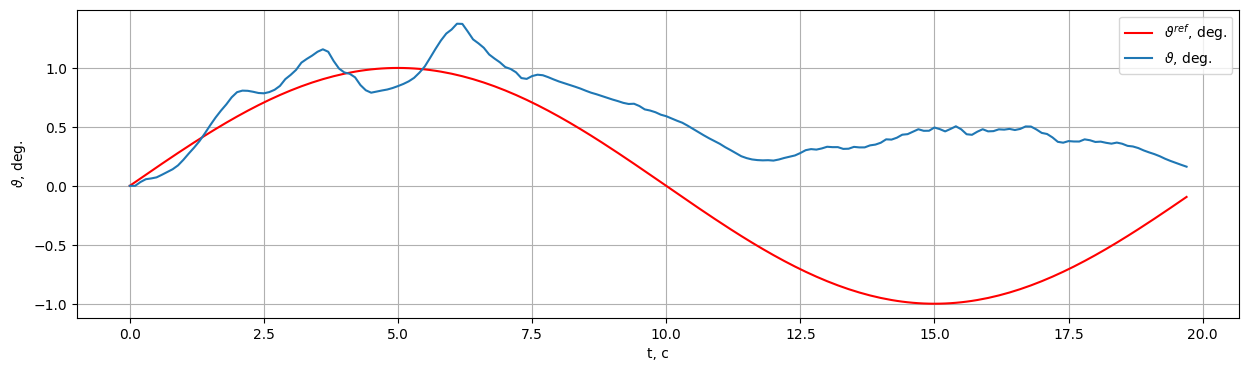

In [6]:
env.unwrapped.model.plot_transient_process('theta', tps, reference_signals[0],to_deg=True , figsize=(15,4))

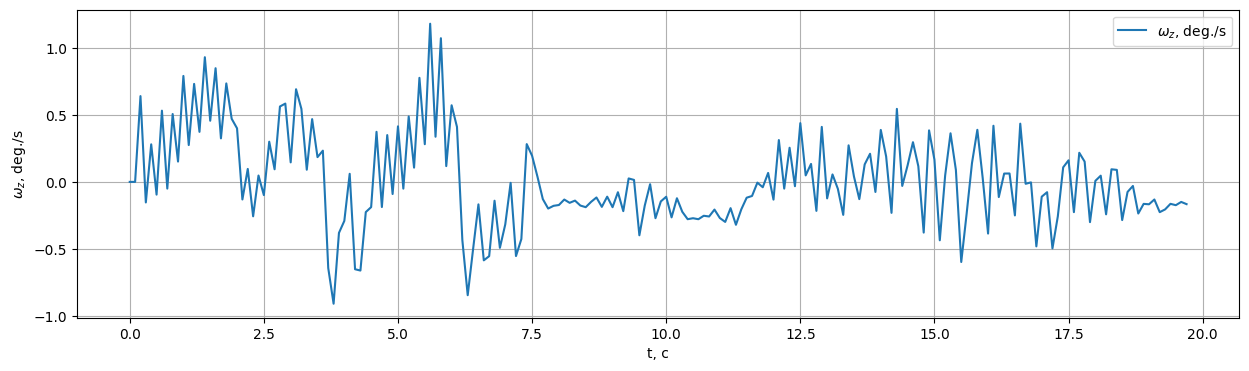

In [7]:
env.unwrapped.model.plot_state(state_name='q', time=tps, to_deg=True, figsize=(15,4))

/Users/asmazaev/TensorAeroSpace-Origin/tensoraerospace/aerospacemodel/base.py:383: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


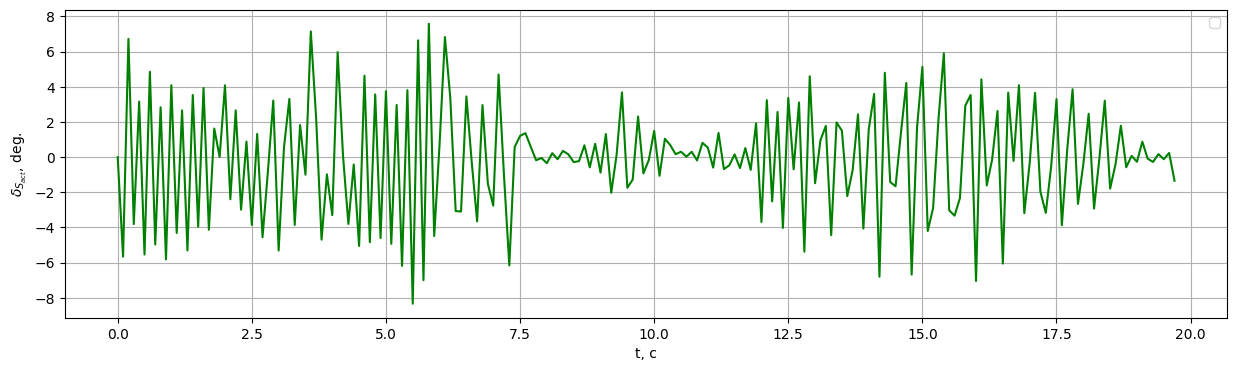

In [8]:
env.unwrapped.model.plot_control(control_name='ele', time=tps, to_deg=True, figsize=(15,4))

In [22]:
agent.save(filepath="./b747_ddpg_grads", include_grads=True)

In [ ]:
# Full run with checkpointing
max_frames = 150_000
max_steps_per_episode = number_time_steps
batch_size = 256

# Optionally resume from checkpoint
# Note: checkpoint now includes observation normalization statistics!
ckpt_path = os.path.join("runs", "ddpg_b747_improved", "ckpt_last.pt")
if os.path.isfile(ckpt_path):
    try:
        agent.load(
            ckpt_path, 
            load_optimizer=True, 
            load_targets=True, 
            load_replay=True, 
            load_noise=True, 
            load_grads=False
        )
        print("Resumed from:", ckpt_path)
        if agent.obs_rms is not None:
            print(f"  Restored obs normalization stats (count: {agent.obs_rms.count:.0f})")
    except Exception as e:
        print("Resume failed:", e)

# Ensure logdir
log_root = os.path.join("runs", "ddpg_b747_improved")
os.makedirs(log_root, exist_ok=True)

try:
    agent.learn(
        max_frames=max_frames,
        max_steps=max_steps_per_episode,
        batch_size=batch_size,
        gamma=0.997,
        soft_tau=3e-3,
        warmup_frames=15_000,
        updates_per_step=2,
        target_value_clip=(-5.0, 5.0),
    )
finally:
    # Save checkpoint (includes obs normalization stats)
    ckpt_out = os.path.join(log_root, "ckpt_last.pt")
    agent.save(ckpt_out, include_grads=False)
    print("Checkpoint saved to:", ckpt_out)
    if agent.obs_rms is not None:
        print(f"  Saved obs normalization stats (count: {agent.obs_rms.count:.0f})")

print("Training finished.")


## Saving and Loading Models (HuggingFace-style)

In addition to regular checkpointing, DDPG supports HuggingFace Hub-style saving:

```python
# Save to a folder (automatically creates config.json + weights)
agent.save("./ddpg_b747_model")

# Load from a local folder
agent = DDPG.load("./ddpg_b747_model", env=env)

# Load from HuggingFace Hub
agent = DDPG.from_pretrained("TensorAeroSpace/ddpg-b747", env=env)
```

In [ ]:
# Example: Inspect final normalization statistics and test the policy
if agent.obs_rms is not None:
    print("=" * 60)
    print("Final Observation Normalization Statistics")
    print("=" * 60)
    state_names = ['u (m/s)', 'w (m/s)', 'q (rad/s)', 'theta (rad)']
    for i, name in enumerate(state_names):
        if i < len(agent.obs_rms.mean):
            print(f"{name:20s}  mean={agent.obs_rms.mean[i]:8.4f}  std={np.sqrt(agent.obs_rms.var[i]):8.4f}")
    print(f"\nTotal samples: {agent.obs_rms.count:.0f}")
    print("=" * 60)

# Test the trained policy
print("\nTesting trained policy on one episode...")
obs, info = env.reset()
episode_reward = 0
for step in range(number_time_steps):
    # Agent automatically normalizes observations internally
    action = agent.policy_net.get_action(agent._normalize_observation(obs))
    obs, reward, terminated, truncated, info = env.step(action)
    episode_reward += reward
    if terminated or truncated:
        break
        
print(f"Test episode reward: {episode_reward:.4f}")


## TensorBoard

You can launch TensorBoard in a separate cell to visualize training logs:

```
%load_ext tensorboard
%tensorboard --logdir runs
```